In [2]:
import os
import sys
import re
import numpy as np
import pandas as pd
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
from dotenv import load_dotenv
from scipy.cluster import hierarchy as sch

load_dotenv()

module_path = str(Path("..").resolve())
if module_path not in sys.path:
    sys.path.append(module_path)

In [3]:



warnings.filterwarnings("ignore")

## Data Loading
merged_studies_df = pd.read_csv(f"../input/02-BERTopic/merged.csv", converters={'Local File': str}, index_col=0)

merged_studies_df['Year'] = merged_studies_df['Year'].convert_dtypes(convert_integer=True)


#iteration = 1
#iteration = 2
#iteration = 3
#iteration = 3.1
#iteration = 4
#iteration = 4.1
#iteration = 5
#iterations = 5.1
#iteration = 6
#iteration = 7
#iteration = 7.1
#iteration = 8.1
#iteration = 9
#iteration = 9.1
#iteration = 10
#iteration = 11
#iteration = 11.1
#iteration = 11.2
#iteration = 12
#iteration = 12.1
#iteration = 13
#iteration = 14
iteration = 15


folder = Path(f"../output/02-BERTopic/{iteration}")
folder.mkdir(parents=True, exist_ok=True)

indices_to_remove = []
# Remove from working set but keep for later!
indices_to_keep = []

if iteration > 1:
    indices_to_remove = indices_to_remove+ [
        83,
        84,
        103,
        120,
        256,
        289,
        315,
        334,
        385,
    ]
  
if iteration > 2:
    indices_to_remove = indices_to_remove+ [
        8,
        39,
        42,
        53,
        71,
        81,
        107,
        116,
        130,
        135,
        146,
        162,
        164,
        205,
        228,
        251,
        258,
        278,
        306,
        320,
        332,
        373,
        394,
        397,
        398
    ]

if iteration > 3.1:
    indices_to_remove = indices_to_remove+ [
        14,
        80,
        90,
        136,
        138,
        242
    ]

if iteration > 4.1:
    indices_to_remove = indices_to_remove + [
        18,
        46,
        63,
        193,
        250,
        293,
        338,
        21,
        211,
        248,
        294,
        317,
        325,
        355,
        41,
        55,
        68,
        129,
        300,
        333,
        27,
        59,
        123,
        206,
        393,
        65,
        67,
        #156, Keep due to table
        280,
        371,
        35,
        165,
        220,
        269,
        95,
        96,
        283, 
        316
    ]

if iteration > 5.1:
    indices_to_remove = indices_to_remove + [5, 19, 61, 62, 82, 97, 99, 100, 101, 109, 112, 119, 131, 139, 151, 159, 168, 172, 173, 176, 177, 179, 185, 191, 210, 212, 214, 217, 231, 232, 239, 244, 257, 261, 262, 272, 274, 277, 285, 292, 297, 326, 327, 329, 330, 335, 361, 362, 366, 368, 372, 378, 388]

if iteration > 6:
    indices_to_remove = indices_to_remove + [
         16, 22, 49,110,114,115,117,118,124,127,140,154,158,192,197,207,223,236,267,282,336,337,347,349,352,375,376
        ]

if iteration > 7.1:
    indices_to_remove = indices_to_remove + [
        6,
        11,
        17,
        25,
        28,
        30,
        34,
        36,
        38,
        47,
        51,
        73,
        88,
        104,
        125,
        126,
        143,
        156,
        170,
        174,
        190,
        216,
        218,
        240,
        243,
        249,
        265,
        268,
        270,
        295,
        298,
        302,
        312,
        314,
        318,
        321,
        343,
        358,
        380,
        153,
    ]
    
if iteration > 8.1:
    indices_to_remove = indices_to_remove + [
        2,
        10,
        26,
        29,
        31,
        32,
        44,
        48,
        50,
        64,
        91,
        92,
        98,
        128,
        141,
        148,
        157,
        161,
        166,
        182,
        189,
        203,
        219,
        222,
        227,
        241,
        247,
        252,
        254,
        271,
        275,
        276,
        288,
        291,
        299,
        308,
        340,
        344,
        356,
        377,
    ]
    
if iteration > 9.1:
    indices_to_remove = indices_to_remove + [
        0,
        1,
        4,
        24,
        45,
        70,
        75,
        94,
        145,
        152,
        184,
        224,
        225,
        307,
        309,
        313,
        328,
        351,
        354
    ]

if iteration > 10:
    indices_to_remove = indices_to_remove + [
        40,
        74,
        106,
        144,
        171,
        186,
        201,
        263,
        290,
        311,
        386,
        392,
        395
    ]

if iteration > 11:
    indices_to_keep = sorted(list(set(indices_to_keep + [
        # Iteration 1
        106,
        # Iteration 2
        94,
        148,
        240,
        247,
        # Iteration 3.1
        301,
        # Iteration 4.1
        156,
        # Iteration 5.1
        13,
        345,
        # Iteration 6
        163,
        348,
        359,
        # Iteration 7.1
        313,
        187,
        167,
        230,
        108,
        60,
        148,
        149,
        # Iteration 8.1
        23,
        12,
        70,
        77,
        94,
        134,
        178,
        181,
        204,
        259,
        273,
        281,
        301,
        305,
        359,
        369,
        370,
        # Iteration 9.1
        12,
        13,
        23,
        60,
        79,
        132,
        134,
        169,
        178,
        181,
        273,
        301,
        305,
        363,
        370,
        # Iteration 10
        12,
        23,
        60,
        69,
        108,
        134,
        167,
        169,
        178,
        181,
        187,
        188,
        230,
        259,
        264,
        266,
        273,
        301,
        305,
        345,
        348,
        370,
        390,
        ## Iteration 11
        43,
        160,
        286,
        357,
        364,
        381,
        384,
    ])))
    
if iteration > 11:
    indices_to_remove = indices_to_remove + [
        85,
        86,
        89,
        111,
        215,
        287,
        296,
        324,
        374,
        382,
        396,
    ]
    
if iteration > 12.1:
    indices_to_keep = indices_to_keep + [
        54,
        56,
        133,
        150,
        155,
        175,
        253,
    ]
    
    indices_to_remove = indices_to_remove + [
        147,
        202,
        238,
        245,
        246,
        323,
        346,
        379,
        387,
        284,
        194,
        87,
        121,
        322,
    ]

if iteration > 13:
    indices_to_remove = indices_to_remove + [
        33,
        66,
        122,
        137,
        180,
        198,
        255,
        353,
        360,
        389,
        105,
        3,
        52,
        304,
        310,
        341,
        199,
        183,
        226,
        233,
        350,
        365,
    ]
    
    indices_to_keep = indices_to_keep + [
        76,
        200,
        209,
        303,
        383,
    ]

if iteration > 14:
    indices_to_keep = indices_to_keep + [
        58,
        72,
        221,
        229,
        319,
        331,
        339,
        391,
        7,
        9,
        15,
        20,
        142,
        234,
        237,
        260,
        279,
    ]
    
    indices_to_remove.extend([  
        93,
        57,
        235,
        37,
        113,
        195,
        367,
        78,
        208,
        213,
        196,
        102,
        342,
    ])


display(merged_studies_df[360:370])

filtered_merged_studies_df = merged_studies_df.drop(index=indices_to_remove + indices_to_keep)
if iteration > 14:
    filtered_merged_studies_df = merged_studies_df[merged_studies_df.index.isin(indices_to_keep)]


filtered_merged_studies_df.reset_index(inplace=True)
original_merged_studies_df = merged_studies_df.copy()

start, end = [0,50]

,Title,DOI,Source,Year,Source title,Cited by,Document Type,Abstract,Author full names,Index Keywords,Author Keywords,Volume,Language of Original Document,Publisher,Conference name,Conference code,ISBN,ieee_file,acm_file
360,Sustainable software products—Towards assessme...,10.1016/j.future.2018.02.044,ACM Digital Library,2018,Future Generation Computer Systems,106.0,Article,Many authors have proposed criteria to assess ...,"Filler, Andreas; Maksimov, Yuliyan V.; Gr\""...","['', 'Application programs; Energy efficiency;...","['Environmental criteria for software, Green s...","['86.0', '86']",English,NaN,NaN,NaN,NaN,NaN,https://dl.acm.org/doi/pdf/10.1016/j.future.20...
361,System architecture and software design for El...,10.1145/2463209.2488852,ACM Digital Library,2013,Proceedings of the 50th Annual Design Automati...,60.0,IEEE Conferences,This paper gives an overview of the system arc...,"Shanker, Shreejith; Mundhenk, Philipp; W. C...",['Batteries;Computer architecture;Vehicles;Sof...,"['electric vehicle, software design, system ar...",NaN,English,"['', 'IEEE']","['', 'Proceedings of the 50th Annual Design Au...",NaN,"['978-1-4503-2071-9', '9781450320719']",https://ieeexplore.ieee.org/stamp/stamp.jsp?ar...,https://dl.acm.org/doi/pdf/10.1145/2463209.248...
362,Task scheduling using Ant Colony Optimization ...,10.1007/s00500-018-3260-4,Scopus,2018,Soft Computing,16.0,Article,The problem of determining a set of real-time ...,"Geetha, R. S.; Srikanth, Umarani",Artificial intelligence; Biomimetics; Cost eff...,Ant Colony Optimization (ACO); Multiprocessors...,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
363,Techniques for low energy software,10.1145/263272.263286,IEEE,1997,Proceedings of 1997 International Symposium on...,41.0,IEEE Conferences,The energy consumption of a system depends upo...,R. Chen; R. M. Owens; M. J. Irwin; D. Ghos...,Energy consumption;Registers;Hardware;Software...,NaN,NaN,English,IEEE,NaN,NaN,0-89791-903-3,https://ieeexplore.ieee.org/stamp/stamp.jsp?ar...,NaN
364,The Energy Cost of the Visitor Pattern,10.1109/ICSME55016.2022.00036,Scopus,2022,NaN,7.0,Conference paper,Design patterns are applied frequently during ...,"Connolly Bree, Deaglan; Ó Cinnéide, Mel",Energy utilization; Object oriented programmin...,Design Patterns; Empirical; Energy Efficiency;...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
365,The Importance of Robust Communication in Larg...,10.1016/j.procs.2024.05.025,Scopus,2024,Procedia Computer Science,3.0,Conference paper,The agile methodology stands out as a prevalen...,"Patriciac, Paola Ariza Colpas; Piñeres-Espit...",Regression analysis; Agile development; Agile ...,Agile development; communication challenges; g...,236,NaN,NaN,NaN,NaN,NaN,NaN,NaN
366,The analysis of impact of energy efficiency re...,10.1109/SC.Companion.2012.121,ACM Digital Library,2012,Proceedings of the 2012 SC Companion: High Per...,0.0,IEEE Conferences,Our underlying machine model has presumed mode...,"J. Shalf; Shalf, John M.; Shalf, John",['Costs;Computer architecture;Codes;Wires;Topo...,['data; energy efficiency; exascale; HPC; many...,NaN,English,"['', 'IEEE']","['', 'Proceedings of the 2012 SC Companion: Hi...",NaN,"['9780769549569', '978-0-7695-4956-9']",https://ieeexplore.ieee.org/stamp/stamp.jsp?ar...,https://dl.acm.org/doi/pdf/10.1109/SC.Companio...
367,The datacenter as a computer: An introduction ...,10.2200/S00193ED1V01Y200905CAC006,Scopus,2009,Synthesis Lectures on Computer Architecture,379.0,Article,As computation continues to move into the clou...,"Hölzle, Urs; Barroso, Luiz André",Cloud computing; Computer organization and des...,Cloud computing; Cluster computing; Computer o...,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
368,The design and implementation of heterogeneous...,10.1145/2541228.2541233,Scopus,2013,ACM Transactions on Architecture and Code Opti...,4.0,Article,"With the emergence of multicore processors, va...","Hsu, Wei-Chung; Luo, Yangchun; Zhai, Antonia",Design and implementations; Dynamic resource a...,Dynamic resource allocation

In [4]:
display(f"Removed the following {len(original_merged_studies_df) - len(filtered_merged_studies_df)} rows:")
removed_rows = original_merged_studies_df[~original_merged_studies_df.apply(tuple, 1).isin(filtered_merged_studies_df.apply(tuple, 1))] # type: ignore
display(removed_rows)
display(f"Keeping the following {len(indices_to_keep)} rows:")
display(original_merged_studies_df[original_merged_studies_df.index.isin(indices_to_keep)])

'Removed the following 321 rows:'

,Title,DOI,Source,Year,Source title,Cited by,Document Type,Abstract,Author full names,Index Keywords,Author Keywords,Volume,Language of Original Document,Publisher,Conference name,Conference code,ISBN,ieee_file,acm_file
0,18th European Conference on Software Architect...,NaN,Scopus,2024,Lecture Notes in Computer Science,0.0,Conference review,The proceedings contain 42 papers. The special...,NaN,NaN,NaN,"['14889 LNCS', '14937 LNCS']",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,19th European Conference on Software Architect...,NaN,Scopus,2026,Lecture Notes in Computer Science,0.0,Conference review,The proceedings contain 27 papers. The special...,NaN,NaN,NaN,15929 LNCS,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1st International Workshop on Mobility Aware T...,NaN,Scopus,2004,Lecture Notes in Computer Science,0.0,Conference review,The proceedings contain 36 papers. The special...,NaN,NaN,NaN,3284,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2012 1st International Workshop on Green and S...,NaN,Scopus,2012,NaN,0.0,Conference review,The proceedings contain 12 papers. The topics ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6GSoft: Software for Edge-to-Cloud Continuum,10.1109/SEAA64295.2024.00082,Scopus,2024,Proceedings of the Euromicro Conference on Sof...,5.0,Conference paper,"In the era of 6G, developing and managing soft...","Su, Ruoyu; Parveen, Risha; Mäkitalo, Niko; ...",Scalability; Software architecture; 6g; Archit...,6G; energy efficiency; scalability; SE; sustai...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
394,Virtual platform-based design space exploratio...,10.1145/2723161,Scopus,2015,ACM Transactions on Embedded Computing Systems,14.0,Article,Networked embedded systems are essential build...,"Rosti, Alberto; Sayyah, Parinaz; Lazarescu, ...",Abstracting; Availability; Design; Embedded sy...,Model-based design; Network simulator; Power m...,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
395,Voyager: Software architecture trade-off explorer,10.1007/978-3-030-59155-7_5,Scopus,2020,Communications in Computer and Information Sci...,2.0,Conference paper,Software engineers must ensure that systems un...,"Mashinchi, Jason; Cámara, Javier",Architectural design; Energy efficiency; Engin...,Quality attributes; Software architecture; Tra...,1269 CCIS,NaN,NaN,NaN,NaN,NaN,NaN,NaN
396,Web-Based Application to Support Decision-Maki...,10.1007/978-3-031-93106-2_11,Scopus,2025,Lecture Notes in Networks and Systems,0.0,Conference paper,Achieving sustainability in today's society re...,"Buhtiyarov, Nikolay; Borissova, Daniela I.; ...",Application programs; Decision making; Softwar...,Decarbonization; Decision-making; Energy Mix; ...,1448 LNNS,NaN,NaN,NaN,NaN,NaN,NaN,NaN
397,Wireless Sensor Network Security,10.1016/B978-0-12-394397-2.00016-7,Scopus,2013,NaN,13.0,Book chapter,"Sensor networks are comprised of tiny, low-cos...","Kupwade Patil, Harsh; Chen, Thomas M.",NaN,Attacks; Microelectronic mechanical systems; O...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


'Keeping the following 78 rows:'

,Title,DOI,Source,Year,Source title,Cited by,Document Type,Abstract,Author full names,Index Keywords,Author Keywords,Volume,Language of Original Document,Publisher,Conference name,Conference code,ISBN,ieee_file,acm_file
7,A Comparative Analysis of Monolith vs Microser...,10.1007/978-3-032-02138-0_17,ACM Digital Library,2026,Software Architecture: 19th European Conferenc...,0.0,Conference paper,As energy demands rise and sustainability beco...,"Capuano, Roberta; O’Dea, Eoan; Muccini, Henry","['', 'Energy utilization; Engineering research...","['software architecture, energy efficiency, su...",15929 LNCS,English,NaN,Software Architecture: 19th European Conferenc...,NaN,978-3-032-02137-3,NaN,https://dl.acm.org/doi/pdf/10.1007/978-3-032-0...
9,A Comparative Study of Software Architectures ...,NaN,ACM Digital Library,2021,NaN,NaN,mastersthesis,"Since its inception in 2009, the Internet of T...","du Plessis, Shani",NaN,NaN,NaN,English,NaN,NaN,NaN,9798819341537,NaN,https://dl.acm.org/doi/pdf/10.5555/AAI29096435
12,A Green Perspective on Structured Parallel Pro...,10.1109/PDP.2015.116,ACM Digital Library,2015,Proceedings of the 2015 23rd Euromicro Interna...,4.0,IEEE Conferences,"Structured parallel programming, and in partic...","Kilpatrick, Peter; M. Torquati; M. Danelutto...","['', 'Skeleton;Parallel programming;Parallel p...","['DVFS, algorithmic skeletons, energy efficien...",NaN,English,"['', 'IEEE']","['', 'Proceedings of the 2015 23rd Euromicro I...",NaN,"['9781479984916', '978-1-4799-8491-6']",https://ieeexplore.ieee.org/stamp/stamp.jsp?ar...,https://dl.acm.org/doi/pdf/10.1109/PDP.2015.116
13,A Highly-efficient Lattice-based Post-Quantum ...,10.46586/tches.v2024.i2.130-153,Scopus,2024,IACR Transactions on Cryptographic Hardware an...,17.0,Article,"Lattice-Based Cryptography (LBC) schemes, like...","Huang, Kejie; Ye, Zewen; Cheung, Ray C.C.; ...",Digital storage; Hardware-software codesign; I...,Internet-of-Things; Lattice-Based Cryptography...,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,A Multi-Sensor-Based System for Cardiovascular...,10.1109/ICSI64877.2025.11009742,IEEE,2025,2025 5th International Conference on Sensors a...,0.0,IEEE Conferences,With the rising prevalence of cardiovascular d...,"Jin, Wenguang; H. Shan; W. Jin; Shan, Haicheng",['Temperature measurement;Heart rate;Accuracy;...,['Cardiovascular Health Monitoring; ECG; Multi...,NaN,English,IEEE,NaN,NaN,979-8-3315-4288-7,https://ieeexplore.ieee.org/stamp/stamp.jsp?ar...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381,Towards Sustainable Software Engineering: A Gr...,10.1109/ICIC63915.2024.11116549,Scopus,2024,NaN,0.0,Conference paper,The field of software engineering is evolving ...,"Rauf, Minahil; Kalsum, Tehmina; Ramzan, Hafi...",Application programs; Energy efficiency; Envir...,carbon emission; energy consumption; green com...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
383,Towards a Knowledge Base of Common Sustainabil...,10.1109/ASE56229.2023.00204,Scopus,2023,NaN,3.0,Conference paper,"With the climate crisis looming, engineering s...","Mehra, Rohit; Podder, Sanjay; Pathania, Priy...",Codes (symbols); Environmental impact; Knowled...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
384,Towards a sustainable architectural design by ...,10.1007/978-3-319-42108-7_6,Scopus,2016,Lecture Notes in Computer Science,6.0,Conference paper,Sustainability is a global concern. It must be...,"Casas, Oscar; Cabezas, Ivan Mauricio; Lopez...",Architectural design; Cloud computing; Compute...,Architecture software design; Cloud computing;...,9787,NaN,NaN,NaN,NaN,NaN,NaN,NaN
390,Understanding the impact of cloud patterns on ...,10.1016/j.jss.2018.03.063,Scopus,2018,Journal of Systems and Software,27.0,Article,Cloud patterns are abstract solutions to recur...,"Khomh, Foutse; Abtahizadeh, S. Amirhossein",Application programming interfaces (API); Appl...,Cloud patterns; Energy consumption; Energy eff...,141,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:

col = 'Abstract'
temp_df = filtered_merged_studies_df
temp_df = temp_df[temp_df[col].notna()]
temp_df = temp_df.reset_index(drop=True)
display(temp_df)
def clean_column(col_name: str, df_to_change: pd.DataFrame):
    # Basic text cleaning for BERTopic (much simpler than Gensim)
    col_clean = f"{col}_clean"
    df_to_change[col_clean] = df_to_change[col].apply(lambda x: re.sub(r"\'", "", x))
    df_to_change[col_clean] = df_to_change[col_clean].apply(lambda x: re.sub(r":", "", x))
    df_to_change[col_clean] = df_to_change[col_clean].apply(lambda x: re.sub(r"\.", "", x))
    df_to_change[col_clean] = df_to_change[col_clean].apply(lambda x: re.sub(r"\(.*\)", "", x))
    return col_clean

col_clean = clean_column(col, temp_df)
# BERTopic works with raw text - no tokenization needed!
documents = temp_df[temp_df[col].notna()][col_clean].tolist()
display(f"Number of documents: {len(documents)}")

,index,Title,DOI,Source,Year,Source title,Cited by,Document Type,Abstract,Author full names,Index Keywords,Author Keywords,Volume,Language of Original Document,Publisher,Conference name,Conference code,ISBN,ieee_file,acm_file
0,7,A Comparative Analysis of Monolith vs Microser...,10.1007/978-3-032-02138-0_17,ACM Digital Library,2026,Software Architecture: 19th European Conferenc...,0.0,Conference paper,As energy demands rise and sustainability beco...,"Capuano, Roberta; O’Dea, Eoan; Muccini, Henry","['', 'Energy utilization; Engineering research...","['software architecture, energy efficiency, su...",15929 LNCS,English,NaN,Software Architecture: 19th European Conferenc...,NaN,978-3-032-02137-3,NaN,https://dl.acm.org/doi/pdf/10.1007/978-3-032-0...
1,9,A Comparative Study of Software Architectures ...,NaN,ACM Digital Library,2021,NaN,NaN,mastersthesis,"Since its inception in 2009, the Internet of T...","du Plessis, Shani",NaN,NaN,NaN,English,NaN,NaN,NaN,9798819341537,NaN,https://dl.acm.org/doi/pdf/10.5555/AAI29096435
2,12,A Green Perspective on Structured Parallel Pro...,10.1109/PDP.2015.116,ACM Digital Library,2015,Proceedings of the 2015 23rd Euromicro Interna...,4.0,IEEE Conferences,"Structured parallel programming, and in partic...","Kilpatrick, Peter; M. Torquati; M. Danelutto...","['', 'Skeleton;Parallel programming;Parallel p...","['DVFS, algorithmic skeletons, energy efficien...",NaN,English,"['', 'IEEE']","['', 'Proceedings of the 2015 23rd Euromicro I...",NaN,"['9781479984916', '978-1-4799-8491-6']",https://ieeexplore.ieee.org/stamp/stamp.jsp?ar...,https://dl.acm.org/doi/pdf/10.1109/PDP.2015.116
3,13,A Highly-efficient Lattice-based Post-Quantum ...,10.46586/tches.v2024.i2.130-153,Scopus,2024,IACR Transactions on Cryptographic Hardware an...,17.0,Article,"Lattice-Based Cryptography (LBC) schemes, like...","Huang, Kejie; Ye, Zewen; Cheung, Ray C.C.; ...",Digital storage; Hardware-software codesign; I...,Internet-of-Things; Lattice-Based Cryptography...,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,15,A Multi-Sensor-Based System for Cardiovascular...,10.1109/ICSI64877.2025.11009742,IEEE,2025,2025 5th International Conference on Sensors a...,0.0,IEEE Conferences,With the rising prevalence of cardiovascular d...,"Jin, Wenguang; H. Shan; W. Jin; Shan, Haicheng",['Temperature measurement;Heart rate;Accuracy;...,['Cardiovascular Health Monitoring; ECG; Multi...,NaN,English,IEEE,NaN,NaN,979-8-3315-4288-7,https://ieeexplore.ieee.org/stamp/stamp.jsp?ar...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,381,Towards Sustainable Software Engineering: A Gr...,10.1109/ICIC63915.2024.11116549,Scopus,2024,NaN,0.0,Conference paper,The field of software engineering is evolving ...,"Rauf, Minahil; Kalsum, Tehmina; Ramzan, Hafi...",Application programs; Energy efficiency; Envir...,carbon emission; energy consumption; green com...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
74,383,Towards a Knowledge Base of Common Sustainabil...,10.1109/ASE56229.2023.00204,Scopus,2023,NaN,3.0,Conference paper,"With the climate crisis looming, engineering s...","Mehra, Rohit; Podder, Sanjay; Pathania, Priy...",Codes (symbols); Environmental impact; Knowled...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75,384,Towards a sustainable architectural design by ...,10.1007/978-3-319-42108-7_6,Scopus,2016,Lecture Notes in Computer Science,6.0,Conference paper,Sustainability is a global concern. It must be...,"Casas, Oscar; Cabezas, Ivan Mauricio; Lopez...",Architectural design; Cloud computing; Compute...,Architecture software design; Cloud computing;...,9787,NaN,NaN,NaN,NaN,NaN,NaN,NaN
76,390,Understanding the impact of cloud patterns on ...,10.1016/j.jss.2018.03.063,Scopus,2018,Journal of Systems and Software,27.0,Article,Cloud patterns are abstract solutions to recur...,"Khomh, Foutse; Abtahizadeh, S. Amirhossein",Application programming interfaces (API); Appl...,Cloud patterns; Energy consumption; Energy eff...,141,NaN,NaN,NaN,NaN,NaN,NaN,NaN


'Number of documents: 78'

In [6]:
import re
import spacy
from spacy.cli import download

def load_spacy_model(model_name: str = "en_core_web_lg"):
    """Load a spaCy model, downloading it if necessary.

    Args:
        model_name (str): The name of the spaCy model to load.

    Returns:
        spacy.language.Language: The loaded spaCy model.
    """
    
    try:
        return spacy.load(model_name)
    except OSError:
        download(model_name)
        return spacy.load(model_name)

## 2. Configure BERTopic Components

In [7]:
from typing import Any, cast

import openai
from bertopic.representation import OpenAI, KeyBERTInspired, MaximalMarginalRelevance, PartOfSpeech
from bertopic.vectorizers import ClassTfidfTransformer

load_spacy_model()

# Configure the embedding model (sentence transformer)
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

n_neighbors=15
min_cluster_size=10
n_components=5

if iteration == 2:
    min_cluster_size = 7
    n_components = 3

if iteration > 3:
    min_cluster_size = 7
    n_components = 3
    
if iteration > 4:
    min_cluster_size = 4
    n_components=3
    
if iteration > 5:
    min_cluster_size = 10

if iteration > 7:
    min_cluster_size = 9
    
if iteration > 8:
    min_cluster_size= 8
    
if iteration > 8.1:
    min_cluster_size= 7
    
if iteration > 9:
    min_cluster_size = 6


if iteration > 11.1:    
    n_neighbors = 2
    
if iteration > 11.2:
    n_neighbors = 14
    
if iteration == 12.1:
    n_neighbors = 2


if iteration > 14:
    min_cluster_size = 2
    
def create_topic_model(n_neighbors: int):
    """Create a BERTopic model with specified parameters.

    Args:
        n_neighbors (int): The number of neighbors for UMAP.

    Returns:
        BERTopic: The configured BERTopic model.
        UMAP: The configured UMAP model.
        HDBSCAN: The configured HDBSCAN model.
        CountVectorizer: The configured CountVectorizer model.
    """
    umap_model = UMAP(
        n_neighbors=n_neighbors,
        n_components=n_components,
        min_dist=0.0,
        metric='cosine',
        random_state=42,
        verbose=False
    )
    
    hdbscan_model = HDBSCAN(
        min_cluster_size=min_cluster_size,  # Reduced from 10 to allow smaller clusters
        min_samples=3,       # Added to handle smaller datasets
        prediction_data=True
    )
    
    vectorizer_model = CountVectorizer(
        stop_words='english',
        max_features=1000,
        ngram_range=(1, 2),
        min_df=1  # Reduced from 2 to be more inclusive with smaller datasets
    )
    
    # Fine-tune topic representations with GPT
    client = openai.OpenAI(api_key=os.getenv("OPENAI_API_KEY", ""))
    main_representation = KeyBERTInspired()
    openai_representation_model = OpenAI(client, model="gpt-4o-mini", chat=True)
    aspect_model1 = PartOfSpeech("en_core_web_lg")
    aspect_model2 = [KeyBERTInspired(top_n_words=30), MaximalMarginalRelevance(diversity=.5)]
    representation_model: dict[str, Any] = {
        "main": main_representation,
        "openai": openai_representation_model,
        "aspect1": aspect_model1,
        "aspect2": aspect_model2
    }
    verbose=False
    topic_model = BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        representation_model=cast(Any, representation_model),
        verbose=verbose,
        calculate_probabilities=True,
    )
    
    return topic_model, umap_model, hdbscan_model, vectorizer_model

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
    
topic_model, umap_model, hdbscan_model, vectorizer_model = create_topic_model(n_neighbors)

topics, probabilities = topic_model.fit_transform(documents)


display(f"Number of topics found: {len(set(topics)) - (1 if -1 in topics else 0)}")
display(f"Number of outliers: {list(topics).count(-1)}")

def linkage_function(x):
    """Custom linkage function for hierarchical topic modeling.
    
    Args:
        x (array-like): The input data for hierarchical clustering.

    Returns:
        array-like: The linkage matrix.
    """
    return sch.linkage(x, 'single', optimal_ordering=True)
hierarchical_topics = topic_model.hierarchical_topics(documents, linkage_function=linkage_function)


# Get topic info
topic_info = topic_model.get_topic_info()
display("\nTopic Information:")
display(topic_info)

'Number of topics found: 5'

'Number of outliers: 16'

100%|██████████| 4/4 [00:00<00:00, 611.53it/s]


'\nTopic Information:'

,Topic,Count,Name,Representation,main,openai,aspect1,aspect2,Representative_Docs
0,-1,16,-1_energy_cloud_software_consumption,"[energy, cloud, software, consumption, energy ...","[software energy, cloud patterns, energy consu...",[Energy efficiency in cloud computing],"[energy, cloud, software, consumption, design,...","[software energy, cloud patterns, energy effic...",[With billions of lines of code being deployed...
1,0,19,0_energy_consumption_design_software,"[energy, consumption, design, software, energy...","[energy consumption, energy efficiency, energy...",[Energy efficiency in software],"[energy, consumption, design, software, patter...","[energy savings, power consumption, design pat...",[Design patterns are applied frequently during...
2,1,18,1_energy_software_consumption_energy consumption,"[energy, software, consumption, energy consump...","[software energy, energy consumption, sustaina...",[Software Energy Efficiency],"[energy, software, consumption, development, e...","[software energy, sustainable software, energy...",[Although software does not consume energy by ...
3,2,14,2_energy_mobile_consumption_applications,"[energy, mobile, consumption, applications, en...","[energy consumption, power consumption, consum...",[Energy consumption in mobile applications],"[energy, mobile, consumption, applications, de...","[power consumption, consumption mobile, androi...",[Context Java and Kotlin are the two main prog...
4,3,7,3_engineering_green_sustainability_software en...,"[engineering, green, sustainability, software ...","[sustainable software, sustainability software...",[Sustainable Software Engineering],"[engineering, green, sustainability, software,...","[sustainability software, green computing, gre...",[The field of software engineering is evolving...
5,4,4,4_patterns_design_power_embedded,"[patterns, design, power, embedded, use, energ...","[design patterns, design pattern, energy consu...",[Energy optimization in embedded systems],"[patterns, design, power, use, energy, systems...","[design patterns, energy consumption, power ma...",[Design patterns are a set of general and reus...


## Visualize UMAP


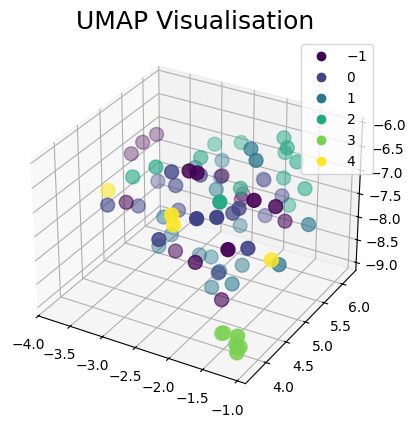

In [9]:
def draw_umap(data, labels, n_neighbors=15, min_dist=0.1, n_components=2, metric='euclidean', title=''):
    """Draw a UMAP visualization of the topic clusters.

    Args:
        data (list of str): The input documents.
        labels (list of int): The topic labels for each document.
        n_neighbors (int): The number of neighbors for UMAP.
        min_dist (float): The minimum distance for UMAP.
        n_components (int): The number of dimensions for UMAP.
        metric (str): The distance metric for UMAP.
        title (str): The title for the plot.
    """
    fit = UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=n_components,
        metric=metric
    )
    word_doc_matrix = vectorizer_model.fit_transform(data)
    u = fit.fit_transform(word_doc_matrix);
    fig = plt.figure()
    if n_components == 1:
        ax = fig.add_subplot(111)
        scatter =ax.scatter(u[:,0], range(len(u)), c=labels, label=labels)
        ax.legend(*scatter.legend_elements())
    if n_components == 2:
        ax = fig.add_subplot(111)
        scatter = ax.scatter(u[:,0], u[:,1], c=labels, label=labels)
        ax.legend(*scatter.legend_elements())
    if n_components == 3:
        ax = fig.add_subplot(projection='3d')
        scatter =ax.scatter(u[:,0], u[:,1], u[:,2], c=labels, s=100, label=labels)
        ax.legend(*scatter.legend_elements())
    plt.title(title, fontsize=18)

draw_umap(documents, topics, n_neighbors=n_neighbors, min_dist=0.0, n_components=n_components, metric='cosine', title='UMAP Visualisation')

## 4. Explore and Visualize Topics

In [10]:
# Display top words for each topic
representative_docs = topic_model.get_representative_docs()
topic_words_and_representative_docs = pd.DataFrame({"Topic": [], "Topic Words": [], "Open AI Topic Name": [], "Doc 1": [], "Doc 2": [], "Doc 3": []})
for topic_id in topic_model.get_topics():  # Show first 10 topics
    topic_words = topic_model.get_topic(cast(int, topic_id))
    if type(topic_words) is bool:
        continue

    topic_row = {
        "Topic": topic_id,
        "Topic Words": ', '.join([f"{word} ({probability:.2f})" for word, probability in topic_words]),
        "Open AI Topic Name": topic_model.get_topic_info(cast(int, topic_id))['openai'][0][0],
        "Doc 1": "",
        "Doc 2": "",
        "Doc 3": ""
    }
    if topic_words:
        words = [word for word, _ in topic_words]
        print(f"Topic {topic_row['Topic']}: {topic_row['Topic Words']}")
        for i, doc in enumerate(representative_docs[cast(int, topic_id)]):  # Show 2 docsc  leu per topic
            print(f"\tDoc {i}: {doc[:150]}...")
            topic_row[f"Doc {i+1}"] = doc
    print("\n")
    topic_words_and_representative_docs.loc[len(topic_words_and_representative_docs)] = topic_row

topic_words_and_representative_docs.to_markdown(f'../output/02-BERTopic/{iteration}/topics_and_representive_docs.md')
topic_words_and_representative_docs

Topic -1: energy (0.07), cloud (0.06), software (0.05), consumption (0.04), energy consumption (0.04), design (0.04), cache (0.03), performance (0.03), power (0.03), patterns (0.03)
	Doc 0: With billions of lines of code being deployed and running on cloud servers, PCs, as well as battery-driven mobile phones, embedded systems, and IoT de...
	Doc 1: Cloud patterns are abstract solutions to recurrent design problems in the cloud Previous work has shown that these patterns can improve the Quality of...
	Doc 2: Cloud Patterns are abstract solutions to recurrent design problems in the cloud Previous work has shown that these patterns can improve the Quality of...


Topic 0: energy (0.08), consumption (0.06), design (0.06), software (0.05), energy consumption (0.05), pattern (0.05), time (0.04), power (0.04), impact (0.04), systems (0.04)
	Doc 0: Design patterns are applied frequently during software evolution in order to make the software more flexible and amenable to extension One little-

,Topic,Topic Words,Open AI Topic Name,Doc 1,Doc 2,Doc 3
0,-1,"energy (0.07), cloud (0.06), software (0.05), ...",Energy efficiency in cloud computing,With billions of lines of code being deployed ...,Cloud patterns are abstract solutions to recur...,Cloud Patterns are abstract solutions to recur...
1,0,"energy (0.08), consumption (0.06), design (0.0...",Energy efficiency in software,Design patterns are applied frequently during ...,With growing concerns regarding climate change...,Design patterns are applied frequently during ...
2,1,"energy (0.09), software (0.09), consumption (0...",Software Energy Efficiency,Although software does not consume energy by i...,Context Software producing organizations have ...,Recent studies show that software systems acco...
3,2,"energy (0.09), mobile (0.07), consumption (0.0...",Energy consumption in mobile applications,Context Java and Kotlin are the two main progr...,Context The demand for green software design i...,"In recent years, the popularities of smartphon..."
4,3,"engineering (0.14), green (0.13), sustainabili...",Sustainable Software Engineering,The field of software engineering is evolving ...,The escalating environmental consequences of s...,This is the first book that presents a compreh...
5,4,"patterns (0.09), design (0.08), power (0.07), ...",Energy optimization in embedded systems,Design patterns are a set of general and reusa...,"Driven by the success of Internet of Things, t...",Resource management is important because of th...


### Checking the Outlier and existing topic probabilities

In [11]:
if -1 in topic_model.get_representative_docs():
    outlier_frame = pd.DataFrame({"index": [], "Abstract": [], "Most probable topic": []})
    for doc in topic_model.get_representative_docs()[-1]:
        print(f"({documents.index(doc)}) Outlier:", doc)
        (topic, topic_probs) = topic_model.transform(doc)
        most_probable_topic = np.where(topic_probs[0] == max(topic_probs[0]))[0][0]
        print(f"Assigned {topic}, other topic with max probability '{topic_model.get_topic_info(most_probable_topic)['openai'][0][0]}'  ({max(topic_probs[0])})\n")
        outlier_row = {
            "index":documents.index(doc),
            "Abstract": doc,
            "Most probable topic": topic_model.get_topic_info(most_probable_topic)['openai'][0][0]
        }
        outlier_frame.loc[len(outlier_frame)] = outlier_row

    outlier_frame.to_markdown(f"../output/02-BERTopic/{iteration}/outliers.md")
    outlier_transformed = topic_model.transform(topic_model.get_representative_docs()[-1])

(77) Outlier: With billions of lines of code being deployed and running on cloud servers, PCs, as well as battery-driven mobile phones, embedded systems, and IoT devices, software energy efficiency will play an increasingly important role in green IT In the past decades, object oriented programming  has become the de facto standard for commercial software design However, very little is known about the impact of OOP and design patterns on software energy efficiency In this paper, we conduct an empirical study on a series of OOP features and design patterns and find out that their influences on performance and energy efficiency vary greatly Some of them have negligible impact while others could degrade performance and increase energy consumption If used appropriately, design patterns can also help improve performance and reduce energy consumption 


Assigned [-1], other topic with max probability 'Energy efficiency in software'  (0.0767727399409542)

(76) Outlier: Cloud patterns are abstract solutions to recurrent design problems in the cloud Previous work has shown that these patterns can improve the Quality of Service  written in Java to monitor the energy consumed at the process-level Results show that cloud patterns can effectively reduce the energy consumption of a cloud-based application, but not in all cases In general, there appear to be a trade-off between an improved response time of the application and the energy consumption Moreover, our findings show that migrating an application to a microservices architecture can improve the performance of the application, while significantly reducing its energy consumption We summarize our contributions in the form of guidelines that developers and software architects can follow during the implementation of a cloud-based application 
Assigned [-1], other topic with max probability 

## 5. BERTopic Visualizations

In [12]:
# 1. Visualize Topics (Interactive)
try:
    fig_topics = topic_model.visualize_topics()
    fig_topics.show()
except Exception as e:
    display("Cant create diagram => ", e)

## 6. Document Clustering Visualization

In [13]:
# 2. Visualize Documents (similar to t-SNE but better)
fig_docs = topic_model.visualize_documents(documents)
fig_docs.show()
fig_docs.write_html(f"../output/02-BERTopic/{iteration}/visualize_documents.html")

In [14]:
topics_over_time = topic_model.topics_over_time(documents, filtered_merged_studies_df["Year"])
fig = topic_model.visualize_topics_over_time(topics_over_time)
fig.show()

fig.write_html(f"../output/02-BERTopic/{iteration}/figure_over_time.html")

## 7. Topic Word Scores and Hierarchy

In [15]:
# 3. Visualize Topic Word Scores
fig_barchart = topic_model.visualize_barchart()
fig_barchart.show()
fig_barchart.write_html(f"../output/02-BERTopic/{iteration}/topic_word_scores.html")

In [16]:
# 4. Visualize Topic Hierarchy
fig_hierarchy = topic_model.visualize_hierarchy()
fig_hierarchy.show()

fig_hierarchy2 = topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)
fig_hierarchy2.show()
fig_hierarchy2.write_html(f"../output/02-BERTopic/{iteration}/topic_hierarchy.html")

## 8. Topic Analysis and Statistics

In [17]:
# Create a dataframe with documents and their topics
import itertools
results_df = pd.DataFrame({
    'Document': documents,
    'Topic': topics,
    'Topic_Probability': probabilities[list(range(0,len(topics))),topics] if probabilities is not None else itertools.repeat(0, len(topics)),
})

# Add topic labels
topic_labels = {}
for topic_id in set(topics):
    if topic_id == -1:
        topic_labels[topic_id] = "Outlier"
    else:
        topic_words = topic_model.get_topic(topic_id)
        if topic_words:
            topic_labels[topic_id] = "_".join([word for word, _ in topic_words[:3]]) # type: ignore

results_df['Topic_Label'] = results_df['Topic'].map(topic_labels)


# Display statistics
print("Topic Distribution:")
topic_counts = results_df['Topic'].value_counts().sort_index()
topic_counts_df = pd.DataFrame({
    "Topic Label": [],
    "Open AI Label": [],
    "Count": []
})
topic_counts_df.index.name = "Topic"
for topic_id, count in topic_counts.head(10).items():
    label = topic_labels.get(topic_id, f"Topic_{topic_id}")

    row = {
        "Topic": topic_id,
        "Topic Label": label,
        "Open AI Label": topic_model.get_topic_info(cast(int, topic_id))['openai'][0][0],
        "Count": count
    }
    print(f"Topic: {row['Topic']} - {row['Open AI Label']}: {row['Count']} documents")
    topic_counts_df.loc[topic_id] = row

topic_counts_df.to_markdown(f"../output/02-BERTopic/{iteration}/topic_counts.md")

Topic Distribution:
Topic: -1 - Energy efficiency in cloud computing: 16 documents
Topic: 0 - Energy efficiency in software: 19 documents
Topic: 1 - Software Energy Efficiency: 18 documents
Topic: 2 - Energy consumption in mobile applications: 14 documents
Topic: 3 - Sustainable Software Engineering: 7 documents
Topic: 4 - Energy optimization in embedded systems: 4 documents


## 9. Model Information and Export

BERTopic Model Information:
Number of topics: 5
Number of documents: 78
Embedding model: SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({})
)

Topic frequencies:
   Topic  Count
1      0     19
0      1     18
3     -1     16
5      2     14
4      3      7
2      4      4


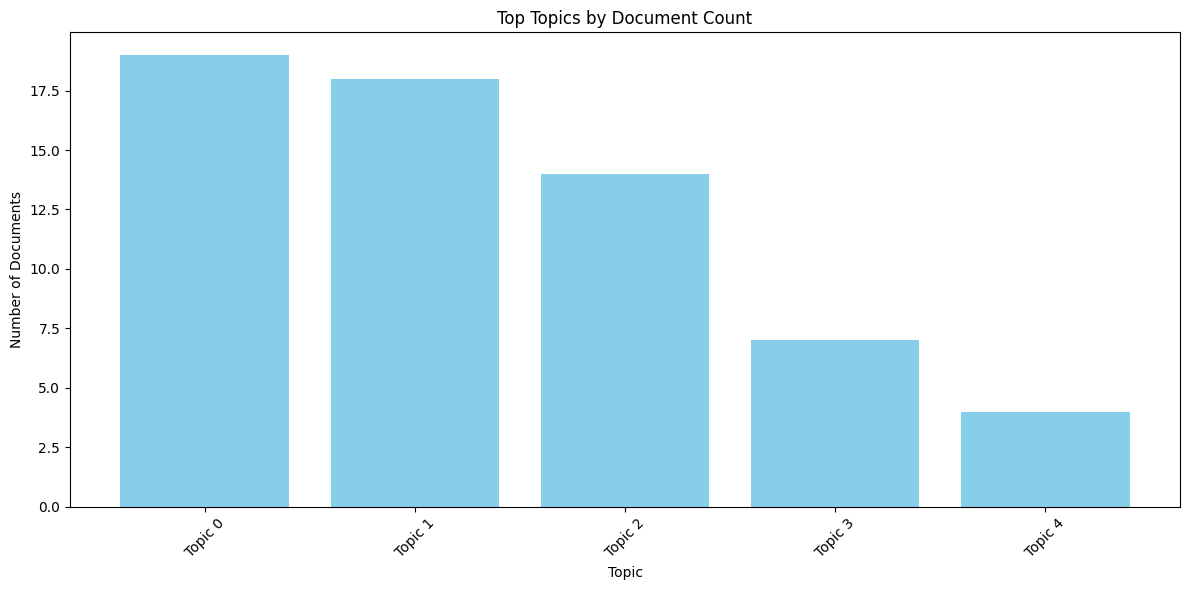

In [18]:
# Display model information
print("BERTopic Model Information:")
print(f"Number of topics: {len(topic_model.get_topic_info()) - 1}")
print(f"Number of documents: {len(documents)}")
print(f"Embedding model: {embedding_model}")

# Get topic frequencies
topic_freq = topic_model.get_topic_freq()
print(f"\nTopic frequencies:")
print(topic_freq)
r = topic_model.representation_model
# Save the model
topic_model.save(f"../output/02-BERTopic/{iteration}/bertopic_model", serialization="safetensors",  save_embedding_model=embedding_model)


# Create a simple frequency plot
plt.figure(figsize=(12, 6))
valid_topics = topic_freq[topic_freq['Topic'] != -1]
x = plt.bar(range(len(valid_topics)), valid_topics['Count'], color='skyblue')
plt.xlabel('Topic')
plt.ylabel('Number of Documents')
plt.title('Top Topics by Document Count')
plt.xticks(range(len(valid_topics)), [f"Topic {t}" for t in valid_topics['Topic']], rotation=45)
plt.tight_layout()
plt.savefig(f"../output/02-BERTopic/{iteration}/topic_distribution.png", bbox_inches='tight', dpi=150)

## Word clouds

6

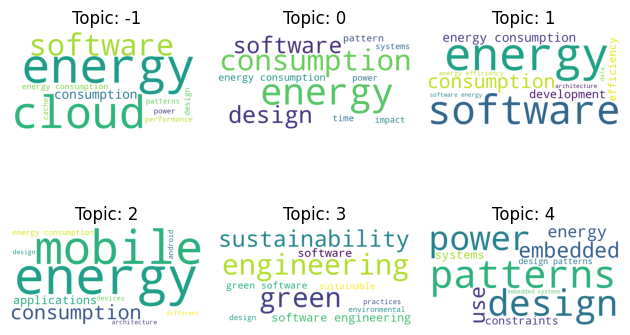

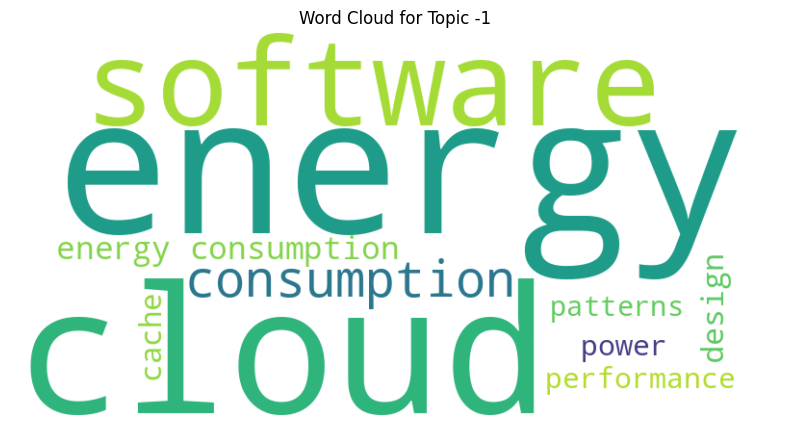

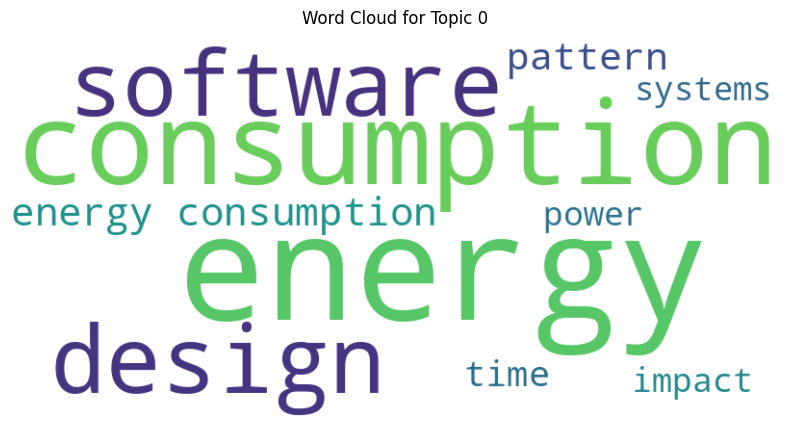

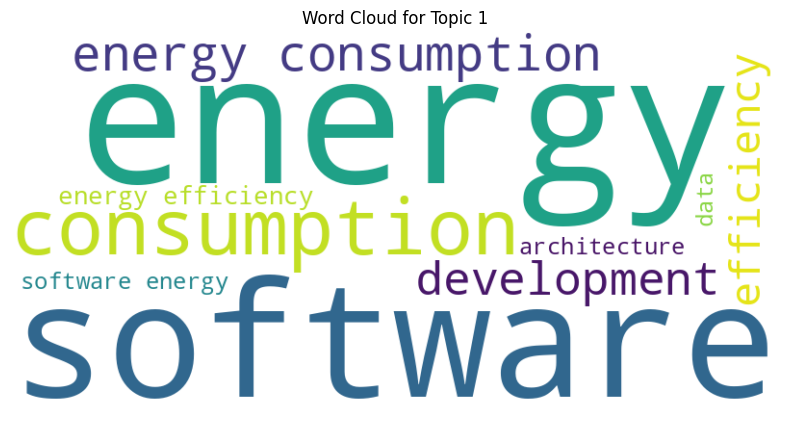

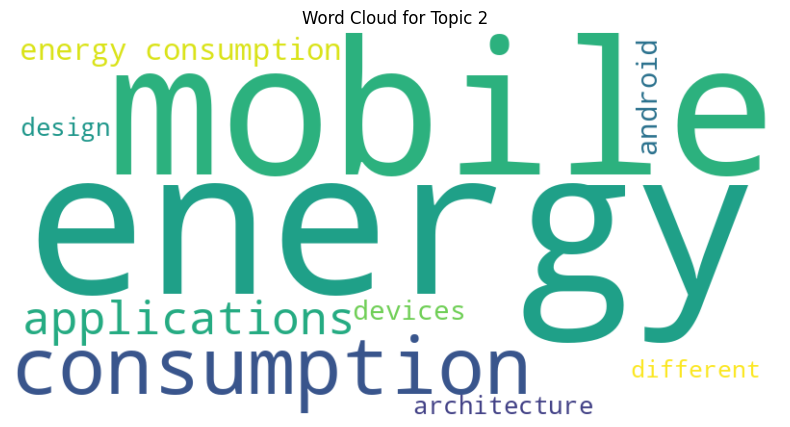

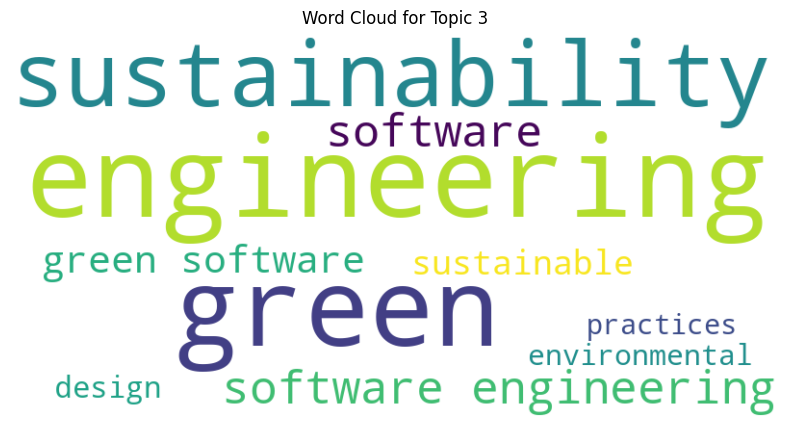

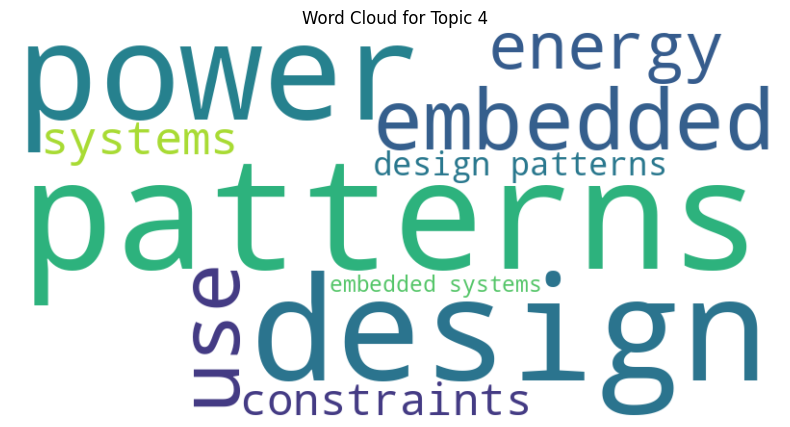

In [19]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import math

# Generate word clouds for each topic
def create_word_clouds(topic_model, num_topics):
    """ Create and save word clouds for each topic in the BERTopic model.

    Args:
        topic_model (BERTopic): The trained BERTopic model.
        num_topics (int): The number of topics to generate word clouds for.
    """
    display(num_topics)
    fig, axes = plt.subplots(math.ceil(num_topics / 3),3)

    for index, topic_id in enumerate(topic_model.get_topics()):
        topic_words = topic_model.get_topic(topic_id)
        if topic_words:
            # Create a dictionary of words and their weights
            word_freq=dict(topic_words)
            
            # Generate the word cloud
            wordcloud = WordCloud(
                width=800, 
                height=400, 
                background_color='white'
            ).generate_from_frequencies(word_freq)
            
            # Plot the word cloud
            plt.figure(figsize=(10, 5))
            axes.flat[index].imshow(wordcloud)
            axes.flat[index].set_title(f"Topic: {topic_id}")
            axes.flat[index].set_axis_off()
            plt.imshow(wordcloud, interpolation='bilinear')
            plt.axis('off')
            plt.title(f"Word Cloud for Topic {topic_id}")
            plt.savefig(f"../output/02-BERTopic/{iteration}/word_cloud_{topic_id}.png", bbox_inches='tight', dpi=150)
            
    [fig.delaxes(ax) for ax in axes.flat if not ax.has_data()]
    fig.tight_layout()
    fig.savefig(f"../output/02-BERTopic/{iteration}/word_clouds.png")

# Call the function to create word clouds for the first 10 topics
create_word_clouds(topic_model, num_topics=len(topic_model.get_topics()))

In [21]:
# Create a list of papers with their corresponding topics
papers_with_topics = results_df[['Document', 'Topic', 'Topic_Label']].values.tolist()

# Print the first 5 papers as an example
for paper in papers_with_topics[:0]:
    display(f"Document: {paper[0][:100]}...")  # Print the first 100 characters of the document
    display(f"Topic: {paper[1]} ({paper[2]})\n")

filtered_merged_studies_df['BERTopic_Topic'] = results_df['Topic']

filtered_merged_studies_df['BERTopic_Topic_Label'] = results_df['Topic_Label']
filtered_merged_studies_df['BERTopic_Probability'] = results_df['Topic_Probability']

topic_model_df = topic_model.get_topic_info()
topic_model_df["openai"] = topic_model_df["openai"].apply(lambda x: x[0])
topic_model_df = topic_model_df.add_prefix("BERTopic_")

merged = filtered_merged_studies_df.merge(topic_model_df, left_on='BERTopic_Topic', right_on='BERTopic_Topic')

#df.drop("Count")
# merged.to_csv("../output/bertopic.csv", index=False)
merged.to_csv(f'../output/02-BERTopic/bertopic_{iteration}.csv')
if iteration > 14:
    merged.to_csv(f'../input/03-Mapping/clustering_results.csv')    
merged

,index,Title,DOI,Source,Year,Source title,Cited by,Document Type,Abstract,Author full names,...,BERTopic_Topic_Label,BERTopic_Probability,BERTopic_Count,BERTopic_Name,BERTopic_Representation,BERTopic_main,BERTopic_openai,BERTopic_aspect1,BERTopic_aspect2,BERTopic_Representative_Docs
0,7,A Comparative Analysis of Monolith vs Microser...,10.1007/978-3-032-02138-0_17,ACM Digital Library,2026,Software Architecture: 19th European Conferenc...,0.0,Conference paper,As energy demands rise and sustainability beco...,"Capuano, Roberta; O’Dea, Eoan; Muccini, Henry",...,energy_software_consumption,0.449017,18,1_energy_software_consumption_energy consumption,"[energy, software, consumption, energy consump...","[software energy, energy consumption, sustaina...",Software Energy Efficiency,"[energy, software, consumption, development, e...","[software energy, sustainable software, energy...",[Although software does not consume energy by ...
1,9,A Comparative Study of Software Architectures ...,NaN,ACM Digital Library,2021,NaN,NaN,mastersthesis,"Since its inception in 2009, the Internet of T...","du Plessis, Shani",...,energy_software_consumption,0.346637,18,1_energy_software_consumption_energy consumption,"[energy, software, consumption, energy consump...","[software energy, energy consumption, sustaina...",Software Energy Efficiency,"[energy, software, consumption, development, e...","[software energy, sustainable software, energy...",[Although software does not consume energy by ...
2,12,A Green Perspective on Structured Parallel Pro...,10.1109/PDP.2015.116,ACM Digital Library,2015,Proceedings of the 2015 23rd Euromicro Interna...,4.0,IEEE Conferences,"Structured parallel programming, and in partic...","Kilpatrick, Peter; M. Torquati; M. Danelutto...",...,energy_consumption_design,0.474216,19,0_energy_consumption_design_software,"[energy, consumption, design, software, energy...","[energy consumption, energy efficiency, energy...",Energy efficiency in software,"[energy, consumption, design, software, patter...","[energy savings, power consumption, design pat...",[Design patterns are applied frequently during...
3,13,A Highly-efficient Lattice-based Post-Quantum ...,10.46586/tches.v2024.i2.130-153,Scopus,2024,IACR Transactions on Cryptographic Hardware an...,17.0,Article,"Lattice-Based Cryptography (LBC) schemes, like...","Huang, Kejie; Ye, Zewen; Cheung, Ray C.C.; ...",...,patterns_design_power,0.388142,4,4_patterns_design_power_embedded,"[patterns, design, power, embedded, use, energ...","[design patterns, design pattern, energy consu...",Energy optimization in embedded systems,"[patterns, design, power, use, energy, systems...","[design patterns, energy consumption, power ma...",[Design patterns are a set of general and reus...
4,15,A Multi-Sensor-Based System for Cardiovascular...,10.1109/ICSI64877.2025.11009742,IEEE,2025,2025 5th International Conference on Sensors a...,0.0,IEEE Conferences,With the rising prevalence of cardiovascular d...,"Jin, Wenguang; H. Shan; W. Jin; Shan, Haicheng",...,Outlier,0.177308,16,-1_energy_cloud_software_consumption,"[energy, cloud, software, consumption, energy ...","[software energy, cloud patterns, energy consu...",Energy efficiency in cloud computing,"[energy, cloud, software, consumption, design,...","[software energy, cloud patterns, energy effic...",[With billions of lines of code being deployed...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,381,Towards Sustainable Software Engineering: A Gr...,10.1109/ICIC63915.2024.11116549,Scopus,2024,NaN,0.0,Conference paper,The field of software engineering is evolving ...,"Rauf, Minahil; Kalsum, Tehmina; Ramzan, Hafi...",...,engineering_green_sustainability,0.636581,7,3_engineering_green_sustainability_software en...,"[engineering, green, sustainability, software ...","[sustainable software, sustainability software...",Sustainable Software Engineering,"[engineering, green, sustainability, software,...","[sustaina